# Data

The original analysis was run on a confidential telecom base-station traffic dataset. `dataset.parquet` is the published dataset for this project: a 1,455-row table of 24-hour traffic profiles, merging two sources.

- **Real profiles**, with their site identifiers replaced by an anonymized `S####` scheme. Only the identifier changes — the traffic values themselves are untouched.
- **Synthetic profiles**, generated from a model calibrated to the aggregate per-hour statistics of the original (confidential) dataset — per-hour mean/std of log-traffic and an hour-to-hour correlation structure — supplementing the real profiles with additional realistic traffic shapes under the same anonymized ID scheme.

No anomaly labels are published alongside this data — intentionally. This mirrors the real-world deployment: a network operations team doesn't get a labeled list of "this station is anomalous" before the fact, so the detection approach below is built and validated (visually and statistically) without ever assuming ground truth exists.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os

pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 200)


DATASET_PATH = "dataset.parquet"

if not os.path.exists(DATASET_PATH):
    raise FileNotFoundError(f"{DATASET_PATH} is required and was not found.")

df = pd.read_parquet(DATASET_PATH)
df.columns = ["site"] + [int(c) for c in df.columns if c != "site"]  # Parquet stores column names as strings
print(f"Loaded dataset from {DATASET_PATH} ({len(df)} rows)")


missing_values = df.isnull().sum()
print("Total missing values:", int(df.isnull().sum().sum()))

hour_cols = [col for col in df.columns if col != "site"]

traffic_summary = df[hour_cols].describe()
display(traffic_summary)

Loaded dataset from dataset.parquet (1455 rows)
Total missing values: 0


,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23
count,1455.000000,1455.000000,1455.000000,1455.000000,1455.000000,1455.000000,1455.000000,1455.000000,1455.000000,1455.000000,1455.000000,1455.000000,1455.000000,1455.000000,1455.000000,1455.000000,1455.000000,1455.000000,1455.000000,1455.000000,1455.000000,1455.000000,1455.000000,1455.000000
mean,69.395436,53.687605,41.225426,31.680315,24.952250,22.316848,27.052708,43.129073,57.207666,64.311918,70.211197,73.207897,80.787606,84.589290,81.663884,81.200490,83.126829,85.852689,87.697832,84.681323,84.299826,88.764354,88.912834,81.829859
std,48.769615,39.080878,31.587532,25.866049,21.242470,18.507317,20.897471,29.116974,36.782130,39.801971,42.825231,44.071101,45.613276,47.762566,47.164244,47.362500,47.915920,49.381266,52.925199,51.451734,52.557539,54.890448,55.973489,52.862564
min,2.200000,2.160000,1.070000,0.770000,0.230000,0.550000,0.200000,1.240000,2.270000,2.220000,2.530000,3.690000,3.900000,4.780000,6.380000,4.610000,4.300000,3.830000,3.240000,3.040000,3.280000,2.660000,2.070000,2.380000
25%,37.760000,28.305142,20.897470,15.606029,12.369348,10.945000,13.373841,23.420000,31.621016,36.636333,41.470000,43.449709,49.455956,50.942170,49.071477,48.937750,49.658011,51.003516,51.425000,49.500000,49.620000,51.354209,51.252269,46.510000
50%,57.085389,43.910000,33.170000,24.910000,19.764061,17.650000,21.919688,36.402884,48.960000,54.645728,60.546888,63.150000,70.514349,74.760000,71.830000,70.620000,73.460000,76.357309,76.580000,73.736234,72.072180,77.820000,76.480000,69.148986
75%,88.980000,67.529670,52.246571,40.160000,31.141678,27.988523,34.165372,54.485000,73.171934,81.585626,88.305000,93.348142,101.822533,108.417318,104.105000,102.875000,105.785537,109.000000,109.102393,105.735000,105.735000,113.019807,111.619791,102.906849
max,500.717794,352.761054,286.261738,268.970813,219.170000,192.200000,195.971048,211.270000,326.406180,307.054573,348.077580,358.057209,411.850510,372.946335,379.010000,420.578506,471.857277,464.901336,558.023594,479.290287,519.480379,481.173704,598.935490,526.599467


In [2]:
print("Number of base stations:", df.shape[0])
print("Number of hourly traffic features:", len(hour_cols))

if len(hour_cols) == 24:
    print("Dataset is suitable for SDA input: each base station has 24 hourly values.")
else:
    print("Warning: hourly columns are not equal to 24. Please check the dataset.")

Number of base stations: 1455
Number of hourly traffic features: 24
Dataset is suitable for SDA input: each base station has 24 hourly values.


Number of site IDs: 1455


0    S0161
1    S0183
2    S0008
3    S0488
4    S0442
Name: site, dtype: str

Shape of X_raw: (1455, 24)


,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23
0,48.014969,33.860674,23.585844,16.987269,13.502025,17.968123,20.144463,32.310222,28.192066,28.545667,39.984740,35.963858,36.537672,35.163197,37.034768,42.718935,39.955705,38.993351,41.019034,32.967305,36.839310,34.577804,33.993582,35.149264
1,72.972728,54.436984,48.675543,30.166796,29.138159,29.962544,33.868999,54.215500,75.070713,89.087895,63.308784,60.066475,63.842782,76.810321,66.623553,59.276105,61.249522,62.700944,65.053588,50.033115,53.245982,42.927445,56.477466,49.607524
2,46.871209,30.728089,23.206761,25.578791,22.322995,20.716570,22.334122,39.323329,47.099909,53.161380,58.774631,62.796675,62.520386,66.937698,59.777059,57.580222,46.695964,38.059029,43.448575,55.483589,48.065026,46.699371,45.861540,45.034210
3,63.759189,65.081884,49.570286,41.649892,34.381497,39.954566,48.632330,71.302024,107.653928,112.118930,107.109529,115.590666,116.454906,139.398484,105.553365,114.783292,101.179993,110.357067,120.657975,116.696215,128.813367,138.621971,109.558421,96.976843
4,69.202095,46.187727,39.714807,28.530461,23.960733,20.147126,27.696545,60.008614,67.683578,72.820893,79.123088,69.591647,70.499478,68.042257,54.799422,65.591187,65.078019,62.361212,63.767962,70.531907,72.023175,80.014577,75.680388,70.204632


Shape of X_raw_np: (1455, 24)
Data type: float32


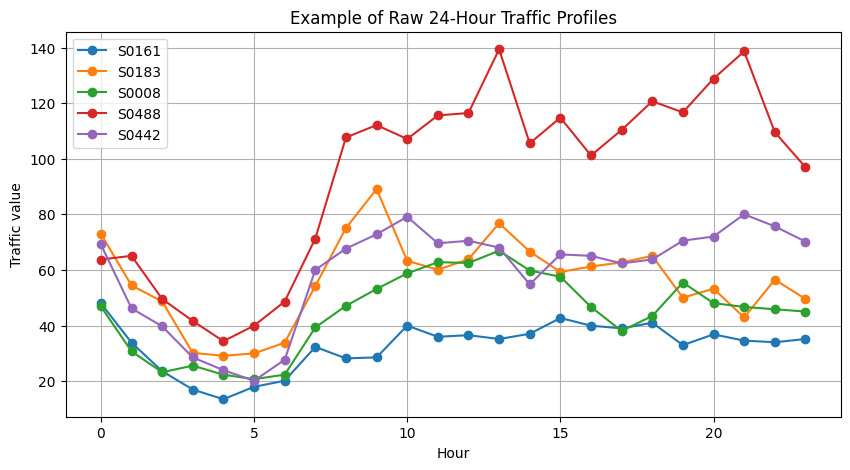

In [3]:
site_ids = df["site"].copy()

print("Number of site IDs:", len(site_ids))
display(site_ids.head())

X_raw = df[hour_cols].copy()

print("Shape of X_raw:", X_raw.shape)
display(X_raw.head())

X_raw_np = X_raw.values.astype("float32")

print("Shape of X_raw_np:", X_raw_np.shape)
print("Data type:", X_raw_np.dtype)

plt.figure(figsize=(10, 5))
for i in range(5):
    plt.plot(hour_cols, X_raw_np[i], marker="o", label=site_ids.iloc[i])
plt.xlabel("Hour")
plt.ylabel("Traffic value")
plt.title("Example of Raw 24-Hour Traffic Profiles")
plt.legend()
plt.grid(True)
plt.show()

# Mean Normalization

Each profile is divided by its daily mean so that its average over the 24 hours equals 1. This removes the absolute traffic magnitude (scale) differences between base stations while preserving the relative hourly variations of the daily curve. A value of 1 corresponds to an hour at the daily-average level, values above 1 are above-average hours, and values below 1 are below-average hours.

In [4]:
daily_mean = X_raw_np.mean(axis=1)
zero_mean_count = np.sum(daily_mean == 0)

safe_mean = np.where(daily_mean == 0, 1.0, daily_mean)
X_norm = X_raw_np / safe_mean[:, np.newaxis]

print(X_norm.shape)

(1455, 24)


In [5]:
X_norm_df = pd.DataFrame(X_norm, columns=hour_cols)
X_norm_df.insert(0, "site", site_ids.values)

display(X_norm_df.head())


,site,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23
0,S0161,1.469828,1.036538,0.722007,0.520012,0.413322,0.550038,0.616660,0.989076,0.863012,0.873836,1.224007,1.100921,1.118486,1.076411,1.133703,1.307706,1.223118,1.193659,1.255669,1.009191,1.127720,1.058491,1.040607,1.075984
1,S0183,1.298428,0.968616,0.866100,0.536768,0.518465,0.533134,0.602643,0.964675,1.335758,1.585171,1.126475,1.068783,1.135976,1.366712,1.185455,1.054720,1.089833,1.115659,1.157521,0.890256,0.947424,0.763823,1.004923,0.882683
2,S0008,1.052225,0.689823,0.520975,0.574225,0.501135,0.465072,0.501385,0.882780,1.057359,1.193434,1.319448,1.409740,1.403537,1.502703,1.341951,1.292634,1.048290,0.854397,0.975389,1.245566,1.079025,1.048367,1.029558,1.010985
3,S0488,0.678332,0.692405,0.527377,0.443112,0.365784,0.425076,0.517398,0.758580,1.145327,1.192830,1.139536,1.229766,1.238961,1.483057,1.122980,1.221177,1.076451,1.174086,1.283677,1.241528,1.370442,1.474796,1.165589,1.031734
4,S0442,1.166933,0.778849,0.669698,0.481100,0.404042,0.339734,0.467038,1.011906,1.141326,1.227955,1.334227,1.173501,1.188810,1.147375,0.924065,1.106043,1.097390,1.051577,1.075299,1.189357,1.214504,1.349260,1.276174,1.183838


In [6]:
from sklearn.model_selection import train_test_split
X_train, X_val = train_test_split(
    X_norm,
    test_size=0.2,
    random_state=42,
    shuffle=True
)

print("Shape of X_train:", X_train.shape)
print("Shape of X_val:", X_val.shape)

Shape of X_train: (1164, 24)
Shape of X_val: (291, 24)


In [7]:
from tensorflow.keras.layers import Input, Dense
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping

In [8]:
input_dim = X_train.shape[1]

def build_autoencoder(input_dim, encoder_units, learning_rate=0.001,
                      output_activation="linear"):
    """Dense symmetric autoencoder.
    encoder_units: list, last entry is the bottleneck (latent) dimension.
    """
    input_layer = Input(shape=(input_dim,), name="input_layer")
    x = input_layer

    #Encoder
    for i, units in enumerate(encoder_units):
        x = Dense(units, activation="relu", name=f"encoder_dense_{i+1}")(x)

    #Decoder (mirror, excluding the bottleneck)
    decoder_units = list(reversed(encoder_units[:-1]))
    for i, units in enumerate(decoder_units):
        x = Dense(units, activation="relu", name=f"decoder_dense_{i+1}")(x)

    output_layer = Dense(input_dim, activation=output_activation,
                         name="output_layer")(x)

    model = Model(inputs=input_layer, outputs=output_layer,
                  name="simple_dense_autoencoder")
    model.compile(optimizer=Adam(learning_rate=learning_rate), loss="mse")
    return model

In [9]:
import itertools
import tensorflow as tf

#Architectures to compare: encoder layer sizes (last entry = bottleneck).
#Shallow (1 encoder layer): that layer IS the bottleneck.
#Deep (2 encoder layers): first layer compresses, second is the bottleneck.
#Bottleneck range 4-8 on a 24-dim input covers the useful compression spectrum.
ARCHITECTURES = {
    "SDA_24_4_24":        [4],
    "SDA_24_6_24":        [6],
    "SDA_24_8_24":        [8],
    "SDA_24_12_4_12_24":  [12, 4],
    "SDA_24_12_6_12_24":  [12, 6],
    "SDA_24_16_8_16_24":  [16, 8],
}
LEARNING_RATES = [1e-3, 5e-4]
SEEDS = [42, 1, 7]          # multiple seeds -> robust, less noisy selection

EPOCHS = 300
BATCH_SIZE = 32
PATIENCE = 20

TUNING_RESULTS_PATH = "tuning_results.csv"
FORCE_RETRAIN_SEARCH = False  # set True to ignore the cache and re-run the search

def arch_text_of(encoder_units):
    decoder_units = list(reversed(encoder_units[:-1]))
    chain = [input_dim] + list(encoder_units) + decoder_units + [input_dim]
    return " -> ".join(map(str, chain))

def sep_ratio_from_model(model, X):
    recon = model.predict(X, verbose=0)
    s = np.sqrt(np.mean((X - recon) ** 2, axis=1))
    return float(np.quantile(s, 0.99) / np.median(s))

if os.path.exists(TUNING_RESULTS_PATH) and not FORCE_RETRAIN_SEARCH:
    tuning_df = pd.read_csv(TUNING_RESULTS_PATH)
    print(f"Loaded cached hyperparameter search results from {TUNING_RESULTS_PATH}")
else:
    tuning_results = []
    for (name, encoder_units), lr in itertools.product(ARCHITECTURES.items(), LEARNING_RATES):
        val_losses, sep_ratios, best_epochs = [], [], []
        for seed in SEEDS:
            tf.keras.backend.clear_session()
            np.random.seed(seed); tf.random.set_seed(seed)

            model = build_autoencoder(input_dim, encoder_units, learning_rate=lr)
            es = EarlyStopping(monitor="val_loss", patience=PATIENCE,
                               restore_best_weights=True)
            h = model.fit(X_train, X_train, validation_data=(X_val, X_val),
                          epochs=EPOCHS, batch_size=BATCH_SIZE, shuffle=True,
                          callbacks=[es], verbose=0)

            val_losses.append(float(np.min(h.history["val_loss"])))
            best_epochs.append(int(np.argmin(h.history["val_loss"]) + 1))
            sep_ratios.append(sep_ratio_from_model(model, X_norm))

        tuning_results.append({
            "model_name": name, "lr": lr,
            "architecture": arch_text_of(encoder_units),
            "mean_val_loss": float(np.mean(val_losses)),
            "std_val_loss": float(np.std(val_losses)),
            "mean_sep_ratio": float(np.mean(sep_ratios)),
            "mean_best_epoch": float(np.mean(best_epochs)),
            "num_params": model.count_params()
        })
        print(f"{name:<20} lr={lr:<7} mean_val_loss={np.mean(val_losses):.3e} "
              f"(+/-{np.std(val_losses):.1e})  sep(q99/med)={np.mean(sep_ratios):6.2f}")

    tuning_df = pd.DataFrame(tuning_results)
    tuning_df.to_csv(TUNING_RESULTS_PATH, index=False)
    print(f"Saved hyperparameter search results to {TUNING_RESULTS_PATH}")

display(tuning_df.sort_values("mean_val_loss").reset_index(drop=True))

Loaded cached hyperparameter search results from tuning_results.csv


,model_name,lr,architecture,mean_val_loss,std_val_loss,mean_sep_ratio,mean_best_epoch,num_params
0,SDA_24_8_24,0.0010,24 -> 8 -> 24,0.007244,0.000397,2.314241,300.000000,416
1,SDA_24_16_8_16_24,0.0010,24 -> 16 -> 8 -> 16 -> 24,0.009070,0.000206,2.217553,299.666667,1088
2,SDA_24_16_8_16_24,0.0005,24 -> 16 -> 8 -> 16 -> 24,0.009518,0.002290,2.184376,300.000000,1088
3,SDA_24_12_6_12_24,0.0010,24 -> 12 -> 6 -> 12 -> 24,0.012409,0.000554,2.594094,300.000000,774
4,SDA_24_8_24,0.0005,24 -> 8 -> 24,0.012598,0.003249,2.477056,300.000000,416
5,SDA_24_12_6_12_24,0.0005,24 -> 12 -> 6 -> 12 -> 24,0.012679,0.002928,2.428837,246.333333,774
6,SDA_24_6_24,0.0010,24 -> 6 -> 24,0.013760,0.002371,2.556136,300.000000,318
7,SDA_24_6_24,0.0005,24 -> 6 -> 24,0.014941,0.001355,2.575754,300.000000,318
8,SDA_24_4_24,0.0010,24 -> 4 -> 24,0.015773,0.001185,2.604496,300.000000,220
9,SDA_24_12_4_12_24,0.0010,24 -> 12 -> 4 -> 12 -> 24,0.016798,0.004619,2.572056,300.000000,724


In [10]:
#Select purely by mean validation reconstruction loss (architecture + lr jointly).
#mean_sep_ratio is reported as a diagnostic, NOT used for selection.
best_row = tuning_df.sort_values("mean_val_loss").iloc[0]

best_model_name = best_row["model_name"]
best_encoder_units = ARCHITECTURES[best_model_name]
best_lr = float(best_row["lr"])

print("Selected architecture:", best_model_name, "=", best_row["architecture"])
print("Encoder units:", best_encoder_units, "| Learning rate:", best_lr)
print(f"Mean val loss: {best_row['mean_val_loss']:.3e} "
      f"(+/-{best_row['std_val_loss']:.1e} over {len(SEEDS)} seeds)")
print(f"Mean sep ratio (q99/med, reported only): {best_row['mean_sep_ratio']:.2f}")

Selected architecture: SDA_24_8_24 = 24 -> 8 -> 24
Encoder units: [8] | Learning rate: 0.001
Mean val loss: 7.244e-03 (+/-4.0e-04 over 3 seeds)
Mean sep ratio (q99/med, reported only): 2.31


In [11]:
import pickle

MODEL_PATH = "sda_autoencoder.keras"
HISTORY_PATH = "sda_training_history.pkl"
FORCE_RETRAIN_MODEL = False  # set True to ignore the cache and retrain the final model

if os.path.exists(MODEL_PATH) and os.path.exists(HISTORY_PATH) and not FORCE_RETRAIN_MODEL:
    autoencoder = tf.keras.models.load_model(MODEL_PATH)
    autoencoder.summary()

    with open(HISTORY_PATH, "rb") as f:
        history_data = pickle.load(f)

    print(f"Loaded cached model from {MODEL_PATH}")
else:
    tf.keras.backend.clear_session()
    np.random.seed(42); tf.random.set_seed(42)

    autoencoder = build_autoencoder(input_dim, best_encoder_units,
                                    learning_rate=best_lr)
    autoencoder.summary()

    early_stop = EarlyStopping(monitor="val_loss", patience=PATIENCE,
                               restore_best_weights=True)

    history = autoencoder.fit(
        X_train, X_train,
        validation_data=(X_val, X_val),
        epochs=EPOCHS, batch_size=BATCH_SIZE, shuffle=True,
        callbacks=[early_stop], verbose=1
    )
    history_data = history.history

    autoencoder.save(MODEL_PATH)
    with open(HISTORY_PATH, "wb") as f:
        pickle.dump(history_data, f)

    print(f"Saved model to {MODEL_PATH} and history to {HISTORY_PATH}")

print("Final training loss:", history_data["loss"][-1])
print("Final validation loss:", history_data["val_loss"][-1])
print("Best epoch:", int(np.argmin(history_data["val_loss"]) + 1))
print("Best validation loss:", float(np.min(history_data["val_loss"])))

Model: "simple_dense_autoencoder"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 24)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ encoder_dense_1 (Dense)         │ (None, 8)              │           200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output_layer (Dense)            │ (None, 24)             │           216 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,250 (4.89 KB)

 Trainable params: 416 (1.62 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 834 (3.26 KB)

Loaded cached model from sda_autoencoder.keras
Final training loss: 0.007686950266361237
Final validation loss: 0.007006857544183731
Best epoch: 300
Best validation loss: 0.007006857544183731


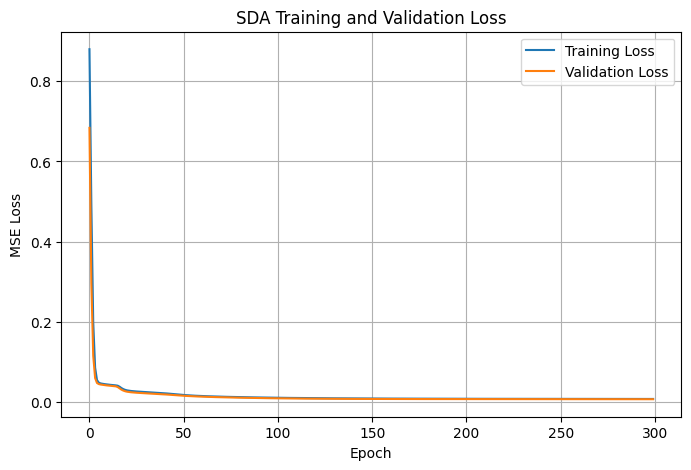

In [12]:
plt.figure(figsize=(8, 5))
plt.plot(history_data["loss"], label="Training Loss")
plt.plot(history_data["val_loss"], label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.title("SDA Training and Validation Loss")
plt.legend()
plt.grid(True)
plt.show()

# Anomaly Detection: Reconstruction Error &amp; Thresholding

The trained autoencoder learns to reconstruct *typical* 24-hour traffic profiles. Because anomalous profiles are rare and structurally different from the bulk of the data, the model should reconstruct them poorly. This gives a natural anomaly score: **per-profile reconstruction error**.

Methodology:
1. Compute the reconstruction error (RMSE across the 24 hours) for every profile in `X_train`, `X_val`, and the full dataset `X_norm`.
2. Use the **training-set** error distribution as the reference for "normal" behavior (the training set is not used elsewhere downstream, and early stopping already used validation loss, so this keeps the threshold derivation independent of the final scoring set).
3. Set a threshold at a high percentile of the training error distribution. Profiles across the full dataset whose error exceeds this threshold are flagged as anomalies.
4. Sanity-check the flags visually by comparing actual vs. reconstructed curves for the most anomalous and most typical profiles.

There is no ground-truth anomaly label for this dataset, by design — this mirrors the real-world deployment, where anomalies aren't known in advance. So "correctness" here is validated qualitatively (does the reconstruction visibly fail on flagged profiles?) and statistically (is the flagged rate consistent with the threshold's designed false-positive rate?), rather than against a labeled test set.

In [13]:
def reconstruction_error(X, X_hat):
    """Per-row RMSE between original and reconstructed profiles."""
    return np.sqrt(np.mean((X - X_hat) ** 2, axis=1))

recon_train = autoencoder.predict(X_train, verbose=0)
recon_val = autoencoder.predict(X_val, verbose=0)
recon_all = autoencoder.predict(X_norm, verbose=0)

err_train = reconstruction_error(X_train, recon_train)
err_val = reconstruction_error(X_val, recon_val)
err_all = reconstruction_error(X_norm, recon_all)

print(f"Train error - mean: {err_train.mean():.4f}, std: {err_train.std():.4f}, max: {err_train.max():.4f}")
print(f"Val error   - mean: {err_val.mean():.4f}, std: {err_val.std():.4f}, max: {err_val.max():.4f}")
print(f"All error   - mean: {err_all.mean():.4f}, std: {err_all.std():.4f}, max: {err_all.max():.4f}")

Train error - mean: 0.0801, std: 0.0349, max: 0.5145
Val error   - mean: 0.0786, std: 0.0287, max: 0.2677
All error   - mean: 0.0798, std: 0.0337, max: 0.5145


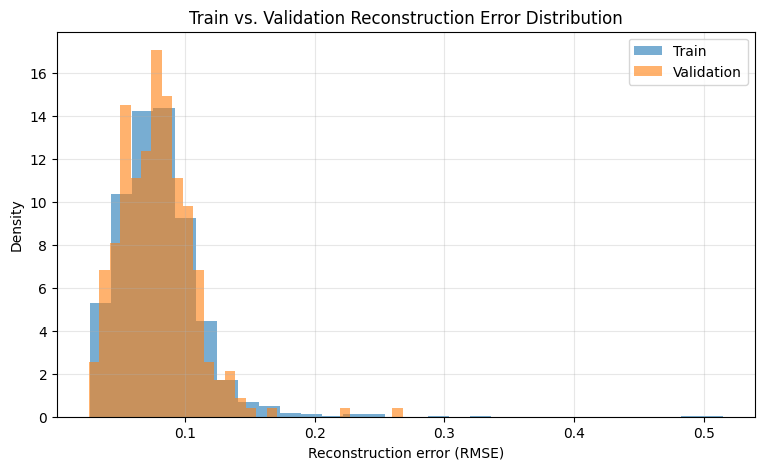

In [14]:
#Sanity check: train and val error distributions should look similar,
#since both are drawn from the same (mostly-normal) population.
plt.figure(figsize=(9, 5))
plt.hist(err_train, bins=30, alpha=0.6, label="Train", density=True)
plt.hist(err_val, bins=30, alpha=0.6, label="Validation", density=True)
plt.xlabel("Reconstruction error (RMSE)")
plt.ylabel("Density")
plt.title("Train vs. Validation Reconstruction Error Distribution")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [15]:
#Threshold = a high percentile of the TRAINING error distribution.
#Rationale: X_train is assumed to be predominantly normal traffic, so its
#error distribution defines what "reconstructs well" looks like. 95th
#percentile means we expect ~5% of normal profiles to sit above threshold
#by chance; anything meaningfully above that rate in the full dataset is
#evidence of real anomalies rather than just distribution tail noise.
THRESHOLD_PERCENTILE = 95
threshold = np.percentile(err_train, THRESHOLD_PERCENTILE)

print(f"Reconstruction-error threshold ({THRESHOLD_PERCENTILE}th percentile of train error): {threshold:.4f}")
print(f"Sites in train exceeding threshold: {np.sum(err_train > threshold)} / {len(err_train)}")
print(f"Sites in val exceeding threshold:   {np.sum(err_val > threshold)} / {len(err_val)}")

Reconstruction-error threshold (95th percentile of train error): 0.1269
Sites in train exceeding threshold: 59 / 1164
Sites in val exceeding threshold:   14 / 291


In [16]:
anomaly_flag = err_all > threshold

results_df = pd.DataFrame({
    "site": site_ids.values,
    "reconstruction_error": err_all,
    "is_anomaly": anomaly_flag
}).sort_values("reconstruction_error", ascending=False).reset_index(drop=True)

n_anomalies = int(anomaly_flag.sum())
print(f"Flagged {n_anomalies} anomalous profiles out of {len(anomaly_flag)} ({n_anomalies / len(anomaly_flag):.1%})")
display(results_df.head(10))

Flagged 73 anomalous profiles out of 1455 (5.0%)


,site,reconstruction_error,is_anomaly
0,S0716,0.514475,True
1,S0720,0.482234,True
2,S0723,0.327181,True
3,S0719,0.288842,True
4,S1283,0.267688,True
5,S0920,0.243974,True
6,S1047,0.242957,True
7,S0727,0.230628,True
8,S0729,0.230133,True
9,S1050,0.225835,True


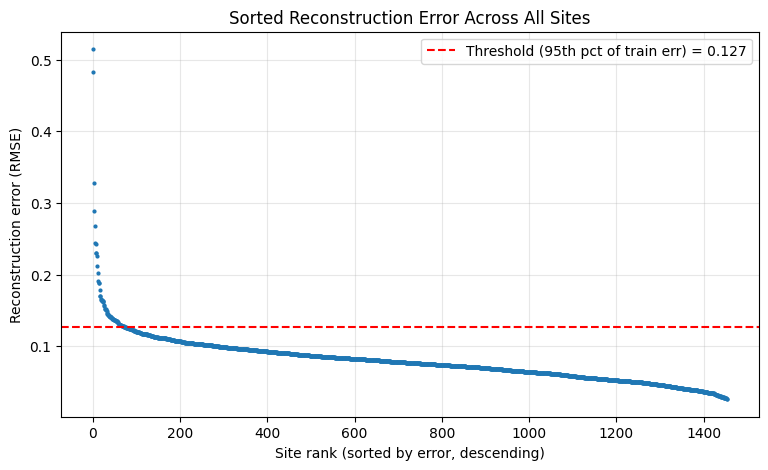

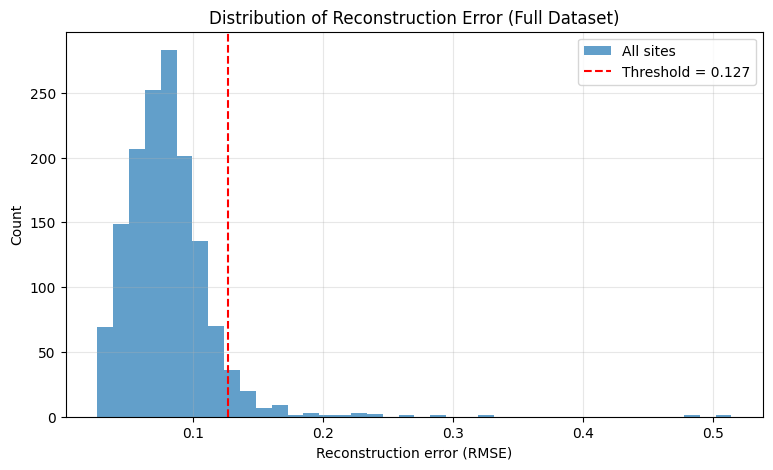

In [17]:
sorted_err = np.sort(err_all)[::-1]

plt.figure(figsize=(9, 5))
plt.plot(sorted_err, marker=".", linestyle="none", markersize=4)
plt.axhline(threshold, color="red", linestyle="--",
           label=f"Threshold ({THRESHOLD_PERCENTILE}th pct of train err) = {threshold:.3f}")
plt.xlabel("Site rank (sorted by error, descending)")
plt.ylabel("Reconstruction error (RMSE)")
plt.title("Sorted Reconstruction Error Across All Sites")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

plt.figure(figsize=(9, 5))
plt.hist(err_all, bins=40, alpha=0.7, label="All sites")
plt.axvline(threshold, color="red", linestyle="--", label=f"Threshold = {threshold:.3f}")
plt.xlabel("Reconstruction error (RMSE)")
plt.ylabel("Count")
plt.title("Distribution of Reconstruction Error (Full Dataset)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

## Visual Validation: Actual vs. Reconstructed Profiles

With no ground-truth labels, the strongest evidence that the flagged sites are genuinely anomalous is visual: the reconstruction should clearly fail to track the actual shape for high-error sites, and should track it closely for low-error (typical) sites.

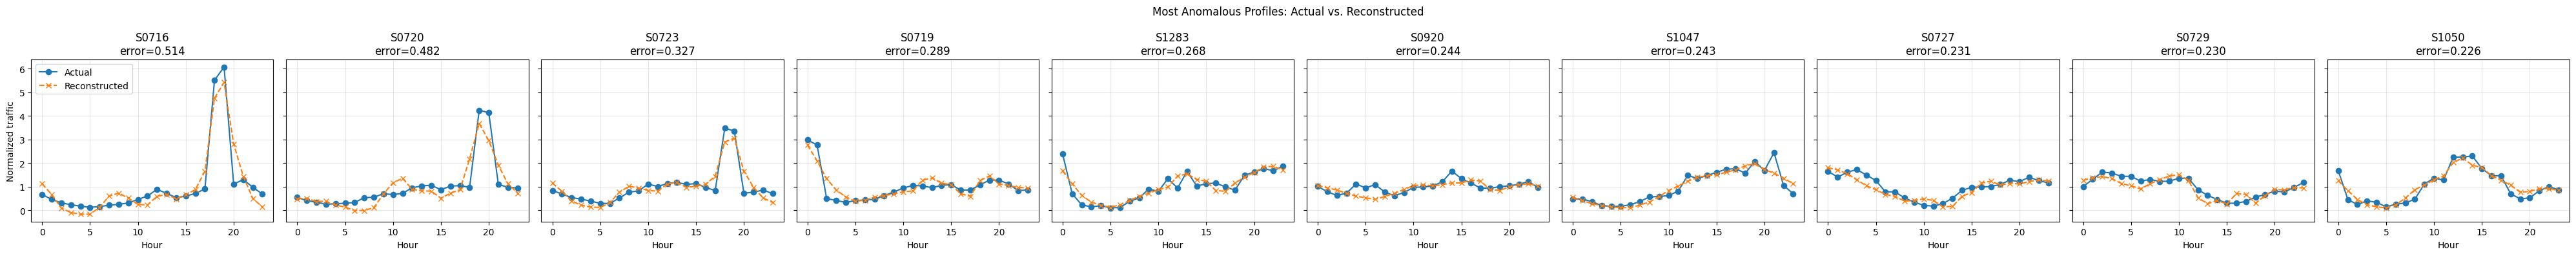

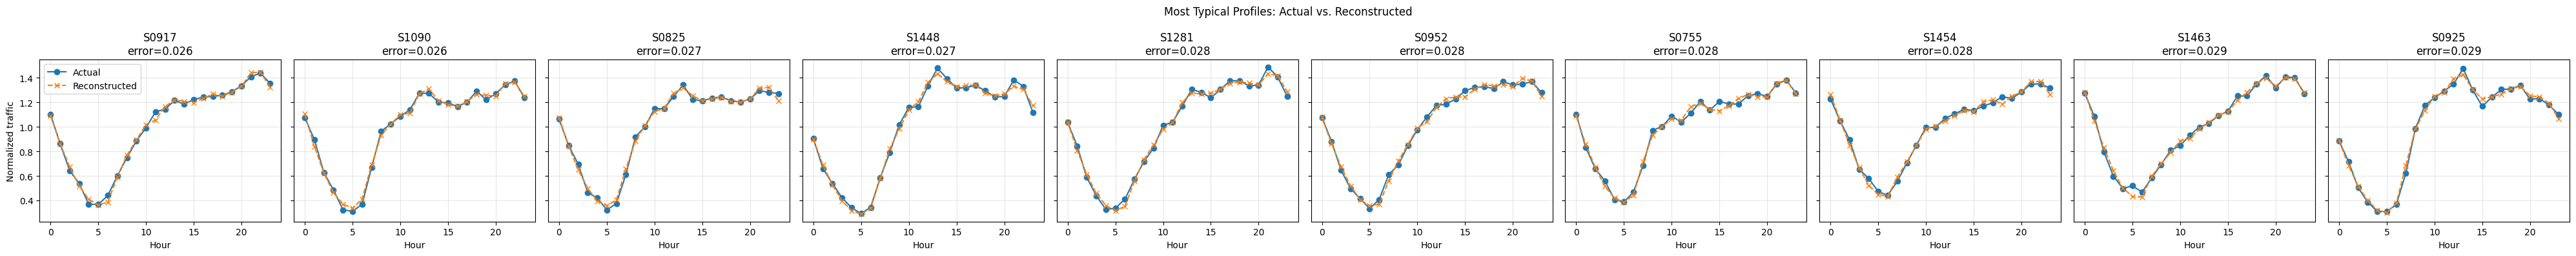

In [18]:
def plot_profile_reconstructions(indices, X, X_hat, site_ids, errors, title):
    n = len(indices)
    fig, axes = plt.subplots(1, n, figsize=(4 * n, 4), sharey=True)
    if n == 1:
        axes = [axes]
    for ax, idx in zip(axes, indices):
        ax.plot(hour_cols, X[idx], marker="o", label="Actual", color="tab:blue")
        ax.plot(hour_cols, X_hat[idx], marker="x", linestyle="--",
               label="Reconstructed", color="tab:orange")
        ax.set_title(f"{site_ids.iloc[idx]}\nerror={errors[idx]:.3f}")
        ax.set_xlabel("Hour")
        ax.grid(True, alpha=0.3)
    axes[0].set_ylabel("Normalized traffic")
    axes[0].legend()
    fig.suptitle(title)
    plt.tight_layout()
    plt.show()

N_EXAMPLES = 10
top_anomaly_idx = np.argsort(err_all)[::-1][:N_EXAMPLES]
top_normal_idx = np.argsort(err_all)[:N_EXAMPLES]

plot_profile_reconstructions(top_anomaly_idx, X_norm, recon_all, site_ids, err_all,
                             "Most Anomalous Profiles: Actual vs. Reconstructed")
plot_profile_reconstructions(top_normal_idx, X_norm, recon_all, site_ids, err_all,
                             "Most Typical Profiles: Actual vs. Reconstructed")

In [19]:
#Export flagged anomalies for downstream review / dashboarding.
OUTPUT_PATH = "anomalous_sites.csv"
results_df[results_df["is_anomaly"]].to_csv(OUTPUT_PATH, index=False)
print(f"Saved {int(anomaly_flag.sum())} flagged sites to {OUTPUT_PATH}")

Saved 73 flagged sites to anomalous_sites.csv


In [20]:
print(f"Summary: {n_anomalies} of {len(anomaly_flag)} sites flagged as anomalous "
     f"({n_anomalies / len(anomaly_flag):.1%}), using a threshold of {threshold:.4f} "
     f"({THRESHOLD_PERCENTILE}th percentile of training reconstruction error).")

Summary: 73 of 1455 sites flagged as anomalous (5.0%), using a threshold of 0.1269 (95th percentile of training reconstruction error).


## Conclusions &amp; Limitations

- A dense autoencoder (`24 → 8 → 24`, single 8-unit bottleneck), selected via a 6-architecture × 2-learning-rate × 3-seed grid search on mean-normalized 24-hour traffic profiles, was used to score every station in the merged (real + synthetic) dataset by reconstruction error.
- Thresholding at the 95th percentile of the training-set error distribution flags a station as anomalous; the flagged count and rate are printed above.
- No ground-truth anomaly labels are used anywhere in this pipeline, by design — this reflects the real-world constraint that anomalies aren't known in advance. Validation is therefore visual (actual vs. reconstructed curves, above) and statistical (the flagged rate tracks the threshold's designed ~5% false-positive rate on normal data), not against a labeled test set.

**Limitations**
- Without ground truth, there's no way to directly measure precision or recall on this dataset — flagged stations are strong *candidates* for review, not confirmed anomalies. This is an inherent limitation of unsupervised detection, not a gap in this particular pipeline.
- The threshold is a single global percentile; it doesn't account for stations whose normal behavior is inherently more variable than others.
- Each day is scored independently; there's no use of history, so a station that is *consistently* unusual every day looks identical to a one-off event.

**Next steps**
- Benchmark against a simpler baseline (e.g., PCA reconstruction error or per-hour z-scores) to see how much the autoencoder's nonlinearity actually buys over a linear method.
- If historical/multi-day data becomes available, extend to sequence models (e.g., LSTM autoencoder) to catch anomalies that unfold over time rather than within a single day.
- Cross-check the flagged stations against actual incident/outage records, if any exist, to get a real precision estimate and close the loop on this unsupervised approach.